# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import sklearn
import itertools
import warnings
import os
import io
import json
import plotly.offline as py #visualization
import plotly.graph_objs as go #visualization
import plotly.tools as tls #visualization
import plotly.figure_factory as ff #visualization
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as skPCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score
from sklearn.cluster import KMeans
from pyspark.sql import functions as f
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from __future__ import print_function

warnings.filterwarnings("ignore")
py.init_notebook_mode(connected=True) #visualization
%matplotlib inline
pd.options.display.max_rows = 2000
pd.options.display.max_columns = None

# Data Import

In [2]:
df = pd.read_csv("dsda_case_study_2019.csv",delimiter=',')
df.head()

,profile_id,primary_sales_product_type,first_booking_time,first_issued_time,last_booking_time,last_issued_time,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,random_number
0,3632279,HOTEL,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2.000823e+06,1.193237e+06,32,18,0.001562
1,3632279,FLIGHT,1405686647701,1.406077e+12,1545735395212,1.545736e+12,1.174169e+06,1.031982e+06,58,33,0.001562
2,17407638,TRAIN,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2.848843e+05,2.527762e+05,62,24,0.004267
3,17407638,HOTEL,1493361893998,1.493362e+12,1547642393838,1.547644e+12,7.374472e+05,5.875060e+05,36,22,0.004267
4,4618047,FLIGHT,1420511473189,1.429178e+12,1546763512498,1.542891e+12,1.604698e+06,1.443118e+06,53,20,0.002460


# Data Assumptions

##### 1) dataset doesn't capture user journey
##### 2) Product Market Fit
##### 3) dataset doesnt have brand loyalty (prime customer, loyal customer,about to end)

# Features Convertion

In [3]:
#rename to second
df['first_booking_time_ms'] = df['first_booking_time']
df['first_issued_time_ms'] = df['first_issued_time']
df['last_booking_time_ms'] = df['last_booking_time']
df['last_issued_time_ms'] = df['last_issued_time']
# convert to date
df['first_booking_time_date'] = pd.to_datetime(df['first_booking_time'],unit='ms')
df['first_issued_time_date'] = pd.to_datetime(df['first_issued_time'],unit='ms')
df['last_booking_time_date'] = pd.to_datetime(df['last_booking_time'],unit='ms')
df['last_issued_time_date'] = pd.to_datetime(df['last_issued_time'],unit='ms')
# drop features
drop_feats = ['first_booking_time','first_issued_time','last_booking_time','last_issued_time']
df.drop(drop_feats,axis=1,inplace=True)
df.head()

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,random_number,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,0.001562,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,0.001562,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,0.004267,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,0.004267,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,0.002460,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872


In [4]:
for i in df['first_issued_time_date'][0:1]:
    print(i)
    print(type(i))
    print(i.strftime("%m/%d/%Y"))
    print(type(i.strftime("%m/%d/%Y")))
    print(datetime.datetime.strptime(i.strftime("%m/%d/%Y"),"%m/%d/%Y"))
    print(type(datetime.datetime.strptime(i.strftime("%m/%d/%Y"),"%m/%d/%Y")))

2016-06-19 02:44:34.396000
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
06/19/2016
<class 'str'>
2016-06-19 00:00:00
<class 'datetime.datetime'>


# Preprocessing EDA + Handle Missing Values

In [5]:
print('how many sum of originial row = ', len(df))
print('how many row after drop duplicated = ', len(df.drop_duplicates()))
print('how many row after drop row number = ', len(df.drop('random_number',axis=1).drop_duplicates()))

how many sum of originial row =  279149
how many row after drop duplicated =  279149
how many row after drop row number =  278486


In [6]:
df = df.drop('random_number',axis=1).drop_duplicates()
df.head()

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872


In [7]:
df.shape

(278486, 14)

In [8]:
display(df['primary_sales_product_type'].value_counts())
display(df['primary_sales_product_type'].value_counts(True))

FLIGHT    136417
HOTEL      93406
TRAIN      41962
TRIP        6701
Name: primary_sales_product_type, dtype: int64

FLIGHT    0.489852
HOTEL     0.335406
TRAIN     0.150679
TRIP      0.024062
Name: primary_sales_product_type, dtype: float64

avg_issued_invoice_amount_idr     0.260261
first_issued_time_ms              0.260261
last_issued_time_ms               0.260261
first_issued_time_date            0.260261
last_issued_time_date             0.260261
profile_id                        0.000000
primary_sales_product_type        0.000000
avg_booking_invoice_amount_idr    0.000000
count_booking                     0.000000
count_issued                      0.000000
first_booking_time_ms             0.000000
last_booking_time_ms              0.000000
first_booking_time_date           0.000000
last_booking_time_date            0.000000
dtype: float64

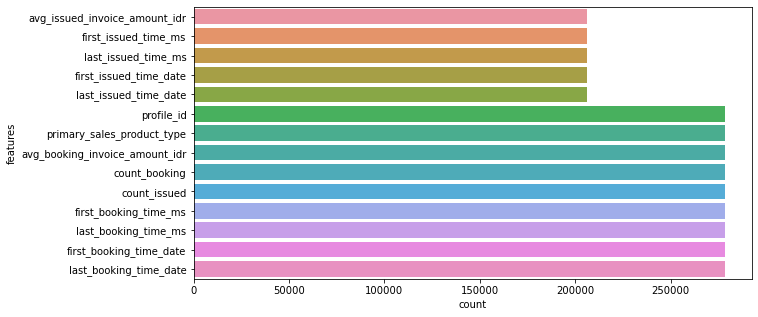

In [9]:
## how many missing values - there 26% of all transactions is not finished only books
features=[]
values=[]
for feats, value in df.isnull().sum().sort_values(ascending=False).items():
    features.append(feats)
    values.append(len(df)-value)
dfcheck = pd.DataFrame(np.array([features,values])).T.rename(columns = {0:'features',1:'count'})
dfcheck['count'] = dfcheck['count'].astype('int64')
#visualize available values each features
plt.figure(figsize=(10,5))
sns.barplot(x='count',y='features',data=dfcheck)

display((df.isnull().sum()/len(df)).sort_values(ascending=False))

avg_issued_invoice_amount_idr     0.293108
first_issued_time_ms              0.293108
last_issued_time_ms               0.293108
first_issued_time_date            0.293108
last_issued_time_date             0.293108
profile_id                        0.000000
primary_sales_product_type        0.000000
avg_booking_invoice_amount_idr    0.000000
count_booking                     0.000000
count_issued                      0.000000
first_booking_time_ms             0.000000
last_booking_time_ms              0.000000
first_booking_time_date           0.000000
last_booking_time_date            0.000000
dtype: float64

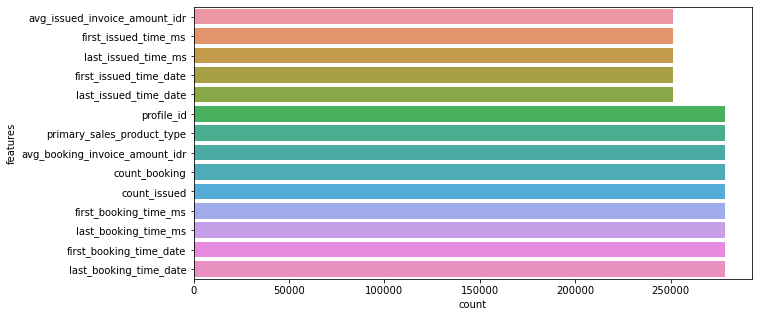

In [10]:
#how many missing values - HOTEL - there 29% of all transactions is not finished only books
features=[]
values=[]
for feats, value in df[df['primary_sales_product_type']=='HOTEL'].isnull().sum().sort_values(ascending=False).items():
    features.append(feats)
    values.append(len(df)-value)
dfcheck = pd.DataFrame(np.array([features,values])).T.rename(columns = {0:'features',1:'count'})
dfcheck['count'] = dfcheck['count'].astype('int64')
#visualize available values each features
plt.figure(figsize=(10,5))
sns.barplot(x='count',y='features',data=dfcheck)

display((df[df['primary_sales_product_type']=='HOTEL'].isnull().sum()/len(df[df['primary_sales_product_type']=='HOTEL'])).sort_values(ascending=False))

avg_issued_invoice_amount_idr     0.240388
first_issued_time_ms              0.240388
last_issued_time_ms               0.240388
first_issued_time_date            0.240388
last_issued_time_date             0.240388
profile_id                        0.000000
primary_sales_product_type        0.000000
avg_booking_invoice_amount_idr    0.000000
count_booking                     0.000000
count_issued                      0.000000
first_booking_time_ms             0.000000
last_booking_time_ms              0.000000
first_booking_time_date           0.000000
last_booking_time_date            0.000000
dtype: float64

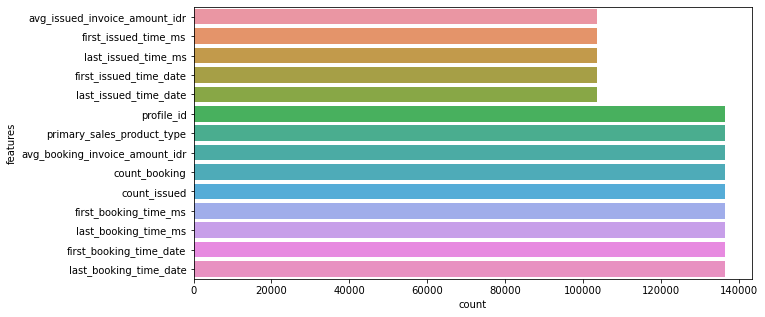

In [11]:
#how many missing values - Flight - there 24% of all transactions is not finished only books
features=[]
values=[]
for feats, value in df[df['primary_sales_product_type']=='FLIGHT'].isnull().sum().sort_values(ascending=False).items():
    features.append(feats)
    values.append(len(df[df['primary_sales_product_type']=='FLIGHT'])-value)
dfcheck = pd.DataFrame(np.array([features,values])).T.rename(columns = {0:'features',1:'count'})
dfcheck['count'] = dfcheck['count'].astype('int64')
#visualize available values each features
plt.figure(figsize=(10,5))
sns.barplot(x='count',y='features',data=dfcheck)

display((df[df['primary_sales_product_type']=='FLIGHT'].isnull().sum()/len(df[df['primary_sales_product_type']=='FLIGHT'])).sort_values(ascending=False))

avg_issued_invoice_amount_idr     0.223083
first_issued_time_ms              0.223083
last_issued_time_ms               0.223083
first_issued_time_date            0.223083
last_issued_time_date             0.223083
profile_id                        0.000000
primary_sales_product_type        0.000000
avg_booking_invoice_amount_idr    0.000000
count_booking                     0.000000
count_issued                      0.000000
first_booking_time_ms             0.000000
last_booking_time_ms              0.000000
first_booking_time_date           0.000000
last_booking_time_date            0.000000
dtype: float64

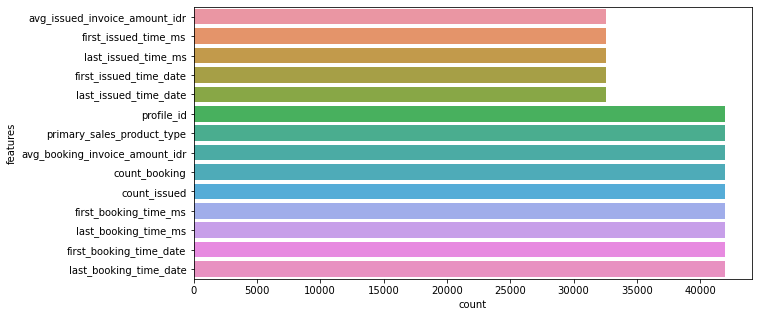

In [12]:
#how many missing values - TRAIN - there 22% of all transactions is not finished only books
features=[]
values=[]
for feats, value in df[df['primary_sales_product_type']=='TRAIN'].isnull().sum().sort_values(ascending=False).items():
    features.append(feats)
    values.append(len(df[df['primary_sales_product_type']=='TRAIN'])-value)
dfcheck = pd.DataFrame(np.array([features,values])).T.rename(columns = {0:'features',1:'count'})
dfcheck['count'] = dfcheck['count'].astype('int64')
#visualize available values each features
plt.figure(figsize=(10,5))
sns.barplot(x='count',y='features',data=dfcheck)

display((df[df['primary_sales_product_type']=='TRAIN'].isnull().sum()/len(df[df['primary_sales_product_type']=='TRAIN'])).sort_values(ascending=False))

avg_issued_invoice_amount_idr     0.439785
first_issued_time_ms              0.439785
last_issued_time_ms               0.439785
first_issued_time_date            0.439785
last_issued_time_date             0.439785
profile_id                        0.000000
primary_sales_product_type        0.000000
avg_booking_invoice_amount_idr    0.000000
count_booking                     0.000000
count_issued                      0.000000
first_booking_time_ms             0.000000
last_booking_time_ms              0.000000
first_booking_time_date           0.000000
last_booking_time_date            0.000000
dtype: float64

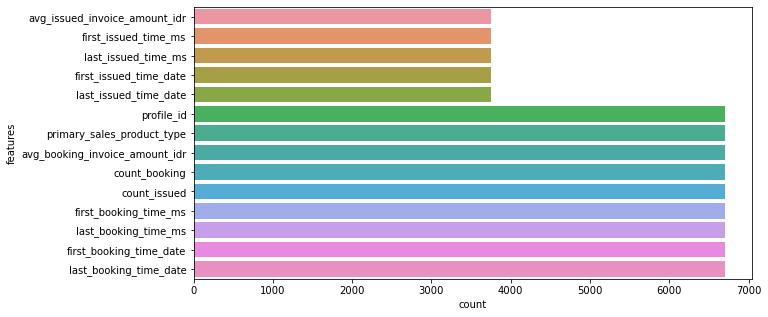

In [13]:
#how many missing values - TRIP - there 43% of all transactions is not finished only books
features=[]
values=[]
for feats, value in df[df['primary_sales_product_type']=='TRIP'].isnull().sum().sort_values(ascending=False).items():
    features.append(feats)
    values.append(len(df[df['primary_sales_product_type']=='TRIP'])-value)
dfcheck = pd.DataFrame(np.array([features,values])).T.rename(columns = {0:'features',1:'count'})
dfcheck['count'] = dfcheck['count'].astype('int64')
#visualize available values each features
plt.figure(figsize=(10,5))
sns.barplot(x='count',y='features',data=dfcheck)

display((df[df['primary_sales_product_type']=='TRIP'].isnull().sum()/len(df[df['primary_sales_product_type']=='TRIP'])).sort_values(ascending=False))

In [14]:
# drop missing value around 26% of all data
df = df.dropna().reset_index().drop('index',axis=1)
# imputation with 0 for avg_issued_invoice_amount_idr due to not having transactions, i mean the 0 is absolut not missing
df['avg_issued_invoice_amount_idr'] = df['avg_issued_invoice_amount_idr'].fillna(0)
df.head()

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872


In [15]:
df.groupby('profile_id',as_index=False)['primary_sales_product_type'].nunique().sort_values(by='primary_sales_product_type',ascending=False)

,profile_id,primary_sales_product_type
53180,13094407,4
39795,10040071,4
90463,22586245,4
22375,6613373,4
22380,6614054,4
...,...,...
64805,15901335,1
64803,15900796,1
64802,15900778,1
64800,15900563,1


In [16]:
pd.options.display.max_rows = 100000
pd.options.display.max_columns = None
df[df['profile_id'].isin([13094407,6614054,22586245])].sort_values(by=['profile_id','last_issued_time_date'])

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date
65808,6614054,TRIP,3.084421e+06,3.084421e+06,1,1,1515470216000,1.515471e+12,1515470216000,1.515471e+12,2018-01-09 03:56:56.000,2018-01-09 04:05:07.000000000,2018-01-09 03:56:56.000,2018-01-09 04:05:07.000000000
184824,6614054,FLIGHT,2.657777e+06,2.598578e+06,9,8,1441707744131,1.441720e+12,1516593465093,1.516594e+12,2015-09-08 10:22:24.131,2015-09-08 13:48:24.243000064,2018-01-22 03:57:45.093,2018-01-22 04:06:52.761999872
114754,6614054,TRAIN,1.247453e+05,1.183715e+05,3,2,1502531446000,1.502532e+12,1517401544000,1.517402e+12,2017-08-12 09:50:46.000,2017-08-12 09:56:21.000000000,2018-01-31 12:25:44.000,2018-01-31 12:28:01.000000000
184825,6614054,HOTEL,1.415564e+06,1.117665e+06,16,8,1442564723172,1.442568e+12,1536908505423,1.536909e+12,2015-09-18 08:25:23.172,2015-09-18 09:23:02.076999936,2018-09-14 07:01:45.423,2018-09-14 07:05:26.068999936
31601,13094407,TRIP,1.468558e+06,1.468558e+06,1,1,1500560483000,1.500562e+12,1500560483000,1.500562e+12,2017-07-20 14:21:23.000,2017-07-20 14:40:22.000000000,2017-07-20 14:21:23.000,2017-07-20 14:40:22.000000000
199264,13094407,TRAIN,3.806855e+05,2.665464e+05,38,13,1485954987950,1.485955e+12,1514252552000,1.513680e+12,2017-02-01 13:16:27.950,2017-02-01 13:16:27.950000128,2017-12-26 01:42:32.000,2017-12-19 10:39:31.000000000
130716,13094407,FLIGHT,7.955038e+05,6.674657e+05,8,3,1500477668319,1.500481e+12,1514111125853,1.514112e+12,2017-07-19 15:21:08.319,2017-07-19 16:12:40.000000000,2017-12-24 10:25:25.853,2017-12-24 10:34:29.415000064
177203,13094407,HOTEL,7.029911e+05,5.560660e+05,47,7,1479005066111,1.479008e+12,1529997782659,1.529999e+12,2016-11-13 02:44:26.111,2016-11-13 03:31:24.347000064,2018-06-26 07:23:02.659,2018-06-26 07:39:51.575000064
88548,22586245,TRIP,3.536237e+06,3.536237e+06,1,1,1520166352000,1.520167e+12,1520166352000,1.520167e+12,2018-03-04 12:25:52.000,2018-03-04 12:35:01.000000000,2018-03-04 12:25:52.000,2018-03-04 12:35:01.000000000
145188,22586245,FLIGHT,6.129143e+05,6.129143e+05,3,3,1520221959828,1.520223e+12,1535705968982,1.535706e+12,2018-03-05 03:52:39.828,2018-03-05 04:07:09.283000064,2018-08-31 08:59:28.982,2018-08-31 09:04:33.507000064


# Define Churn Label

In [17]:
print("""target days is formed to create label churn that hasn't bought in 1 year or in a days is more than 365 days not bought
using last_trx_time because my assumptions is last booking date can generate revenue or the company get revenue from 
the booking, so if last booking date not generated revenue for the company, i think we can use last_issued_time as last transactions date""")
df['target_days'] = (pd.to_datetime('2019-02-01')-df['last_issued_time_date']).dt.days
df.loc[df['target_days']==-1,'target_days'] = 0
df['is_churn'] = np.where(df['target_days'] > 365, 1, 0)
df.drop('target_days',axis=1,inplace=True)
df.head()

target days is formed to create label churn that hasn't bought in 1 year or in a days is more than 365 days not bought
using last_trx_time because my assumptions is last booking date can generate revenue or the company get revenue from 
the booking, so if last booking date not generated revenue for the company, i think we can use last_issued_time as last transactions date


,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000,0
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128,0
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000,0
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064,0
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872,0


In [18]:
#how many churns proportion each product and all
display(df['primary_sales_product_type'].value_counts(True))
display(Counter(df['is_churn']))
display(Counter(df[df['primary_sales_product_type']=='FLIGHT']['is_churn']))
display(Counter(df[df['primary_sales_product_type']=='HOTEL']['is_churn']))
display(Counter(df[df['primary_sales_product_type']=='TRAIN']['is_churn']))
display(Counter(df[df['primary_sales_product_type']=='TRIP']['is_churn']))

FLIGHT    0.503012
HOTEL     0.320513
TRAIN     0.158252
TRIP      0.018223
Name: primary_sales_product_type, dtype: float64

Counter({0: 124204, 1: 81803})

Counter({0: 57571, 1: 46053})

Counter({0: 40347, 1: 25681})

Counter({0: 23580, 1: 9021})

Counter({0: 2706, 1: 1048})

In [19]:
df.head().T

,0,1,2,3,4
profile_id,3632279,3632279,17407638,17407638,4618047
primary_sales_product_type,HOTEL,FLIGHT,TRAIN,HOTEL,FLIGHT
avg_booking_invoice_amount_idr,2000822.71875,1174168.913793,284884.274194,737447.194444,1604697.660377
avg_issued_invoice_amount_idr,1193236.777778,1031981.666667,252776.166667,587505.954545,1443118.3
count_booking,32,58,62,36,53
count_issued,18,33,24,22,20
first_booking_time_ms,1436705255370,1405686647701,1493348364000,1493361893998,1420511473189
first_issued_time_ms,1466304274396.0,1406077331494.0,1493349147000.0,1493362372547.0,1429178498531.0
last_booking_time_ms,1538717915528,1545735395212,1548320804000,1547642393838,1546763512498
last_issued_time_ms,1538718482608.0,1545735761270.0,1548322802000.0,1547643603911.0,1542891221530.0


# EDA + Features Building

In [20]:
display(df.head())
display(df.info())

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000,0
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128,0
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000,0
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064,0
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206007 entries, 0 to 206006
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   profile_id                      206007 non-null  int64         
 1   primary_sales_product_type      206007 non-null  object        
 2   avg_booking_invoice_amount_idr  206007 non-null  float64       
 3   avg_issued_invoice_amount_idr   206007 non-null  float64       
 4   count_booking                   206007 non-null  int64         
 5   count_issued                    206007 non-null  int64         
 6   first_booking_time_ms           206007 non-null  int64         
 7   first_issued_time_ms            206007 non-null  float64       
 8   last_booking_time_ms            206007 non-null  int64         
 9   last_issued_time_ms             206007 non-null  float64       
 10  first_booking_time_date         206007 non-null  datetim

None

In [21]:
#add features month for cohort analysis
df['first_booking_time_month'] = [i.strftime('%Y-%m') for i in df['first_booking_time_date']]
df['last_booking_time_month'] = [i.strftime('%Y-%m') for i in df['last_booking_time_date']]
df['first_issued_time_month'] = [i.strftime('%Y-%m') for i in df['first_issued_time_date']]
df['last_issued_time_month'] = [i.strftime('%Y-%m') for i in df['last_issued_time_date']]
df[df['profile_id']==15909066]

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn,first_booking_time_month,last_booking_time_month,first_issued_time_month,last_issued_time_month
65933,15909066,TRAIN,253533.250000,279199.00,8,1,1490553494000,1.490601e+12,1490600685000,1.490601e+12,2017-03-26 18:38:14.000,2017-03-27 07:54:17.000000000,2017-03-27 07:44:45.000,2017-03-27 07:54:17.000000000,1,2017-03,2017-03,2017-03,2017-03
114827,15909066,HOTEL,463414.875000,208413.50,24,2,1489013087665,1.500879e+12,1514746049354,1.501120e+12,2017-03-08 22:44:47.665,2017-07-24 06:46:06.796999936,2017-12-31 18:47:29.354,2017-07-27 01:52:17.353999872,1,2017-03,2017-12,2017-07,2017-07
154857,15909066,FLIGHT,965616.363636,717775.25,11,4,1488954762507,1.488955e+12,1534391831536,1.532587e+12,2017-03-08 06:32:42.507,2017-03-08 06:42:55.555000064,2018-08-16 03:57:11.536,2018-07-26 06:43:36.705999872,0,2017-03,2018-08,2017-03,2018-07


<AxesSubplot:xlabel='periods', ylabel='month'>

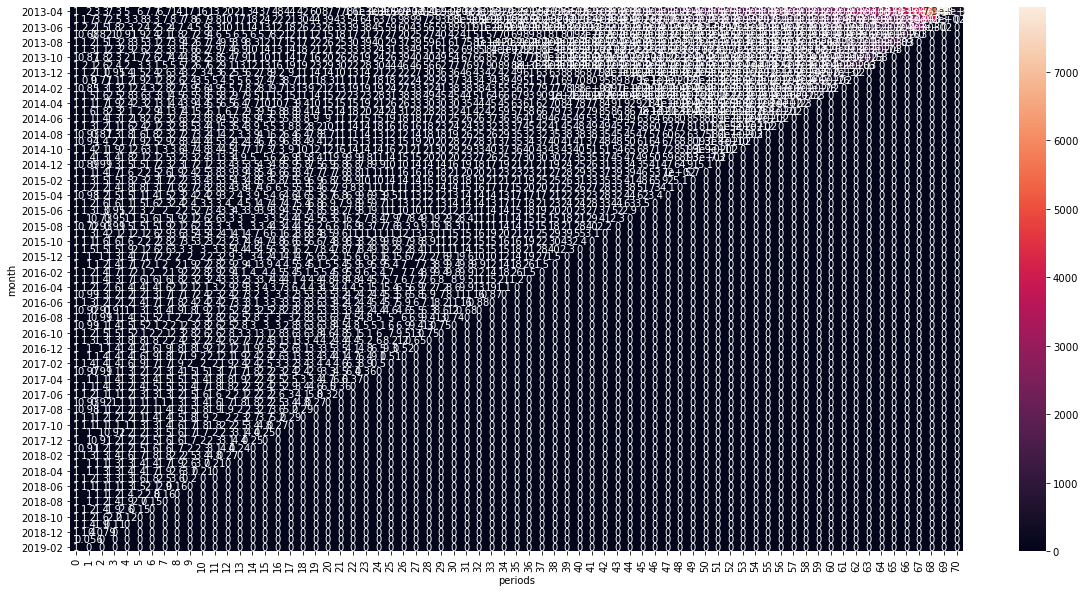

In [22]:
# All Product
df_trx_cohort_clean = df[df['last_issued_time_month'].notna()]
df1 = df_trx_cohort_clean.groupby('last_issued_time_month',as_index=False)['profile_id'].count()
df1.columns = ['acq_month','cohort_idx']
df1['acq_month'] = pd.to_datetime(df1['acq_month'])
df1['month'] = [i.strftime("%Y-%m")for i in df1['acq_month']]
df1 = df1.groupby('month',as_index=False)['cohort_idx'].sum()
df1.columns =  ['last_trx_time_month','count_trx']
dfs = df1.copy()
dfesis = []
for i in range(len(dfs)):
    #real value
    dfm = dfs.copy().loc[i:]
    dfm['month'] = df1['last_trx_time_month'][i]
    dfm['periods'] = [i for i in range(len(dfm))]
    dfm['prob'] = [(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfm['pcg'] = [100*(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfesis.append(dfm)
dfesis = pd.concat(dfesis,axis=0).sort_values(by=['periods','last_trx_time_month'])
dfesis = dfesis.reset_index().drop('index',axis=1)
dfpivot_trx = dfesis.pivot(index='month',columns='periods',values='count_trx').fillna(0)
dfpivot_prob = dfesis.pivot(index='month',columns='periods',values='prob').fillna(0)
dfpivot_pcg = dfesis.pivot(index='month',columns='periods',values='pcg').fillna(0)
with pd.ExcelWriter('new_pivot_all.xlsx') as writer1:
    dfpivot_trx.to_excel(writer1, sheet_name = 'df_trx', index = True)
    dfpivot_prob.to_excel(writer1, sheet_name = 'df_prob', index = True)
    dfpivot_pcg.to_excel(writer1, sheet_name = 'df_pcg', index = True)
plt.figure(figsize=(20,10))
sns.heatmap(dfpivot_prob,annot=True)

<AxesSubplot:xlabel='periods', ylabel='month'>

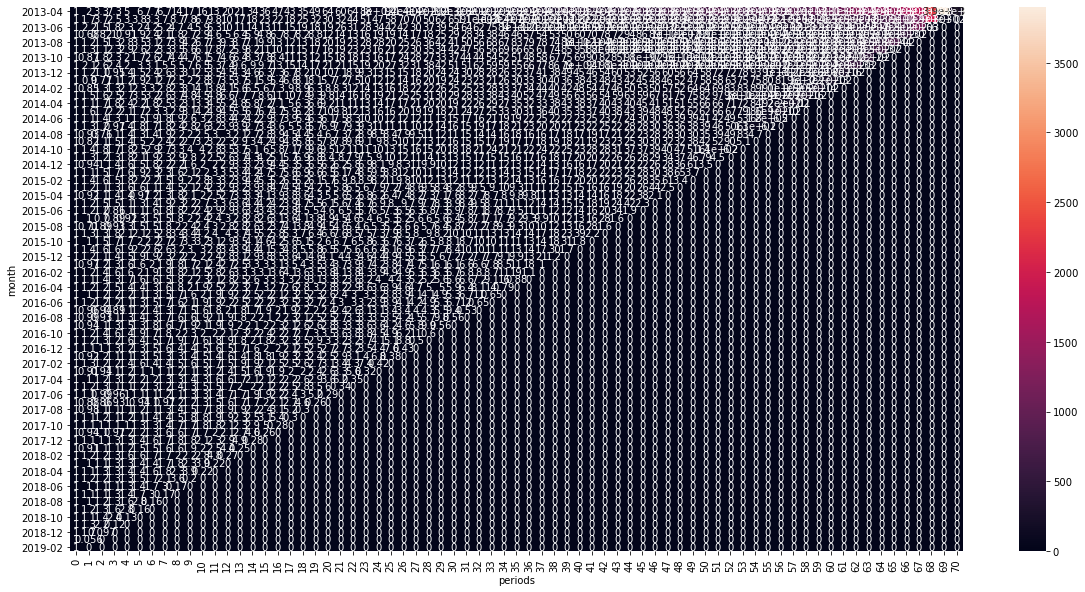

In [23]:
#flight
prod = 'FLIGHT'
df_trx_cohort_clean = df[df['last_issued_time_month'].notna()]
df_trx_cohort_clean = df_trx_cohort_clean[['profile_id','last_issued_time_month','primary_sales_product_type']].copy()
df_trx_cohort_clean = df_trx_cohort_clean[df_trx_cohort_clean['primary_sales_product_type']==prod]
df_trx_cohort_clean = df_trx_cohort_clean.groupby('last_issued_time_month',as_index=False)['profile_id'].count()
df1 = df_trx_cohort_clean.copy()
df1.columns =  ['last_trx_time_month','count_trx']
dfs = df1.copy()
dfesis = []
for i in range(len(dfs)):
    #real value
    dfm = dfs.copy().loc[i:]
    dfm['month'] = df1['last_trx_time_month'][i]
    dfm['periods'] = [i for i in range(len(dfm))]
    dfm['prob'] = [(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfm['pcg'] = [100*(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfesis.append(dfm)
dfesis = pd.concat(dfesis,axis=0).sort_values(by=['periods','last_trx_time_month'])
dfesis = dfesis.reset_index().drop('index',axis=1)
dfpivot_trx = dfesis.pivot(index='month',columns='periods',values='count_trx').fillna(0)
dfpivot_prob = dfesis.pivot(index='month',columns='periods',values='prob').fillna(0)
dfpivot_pcg = dfesis.pivot(index='month',columns='periods',values='pcg').fillna(0)
with pd.ExcelWriter(f'new_pivot_{prod}.xlsx') as writer1:
    dfpivot_trx.to_excel(writer1, sheet_name = 'df_trx', index = True)
    dfpivot_prob.to_excel(writer1, sheet_name = 'df_prob', index = True)
    dfpivot_pcg.to_excel(writer1, sheet_name = 'df_pcg', index = True)
plt.figure(figsize=(20,10))
sns.heatmap(dfpivot_prob,annot=True)

<AxesSubplot:xlabel='periods', ylabel='month'>

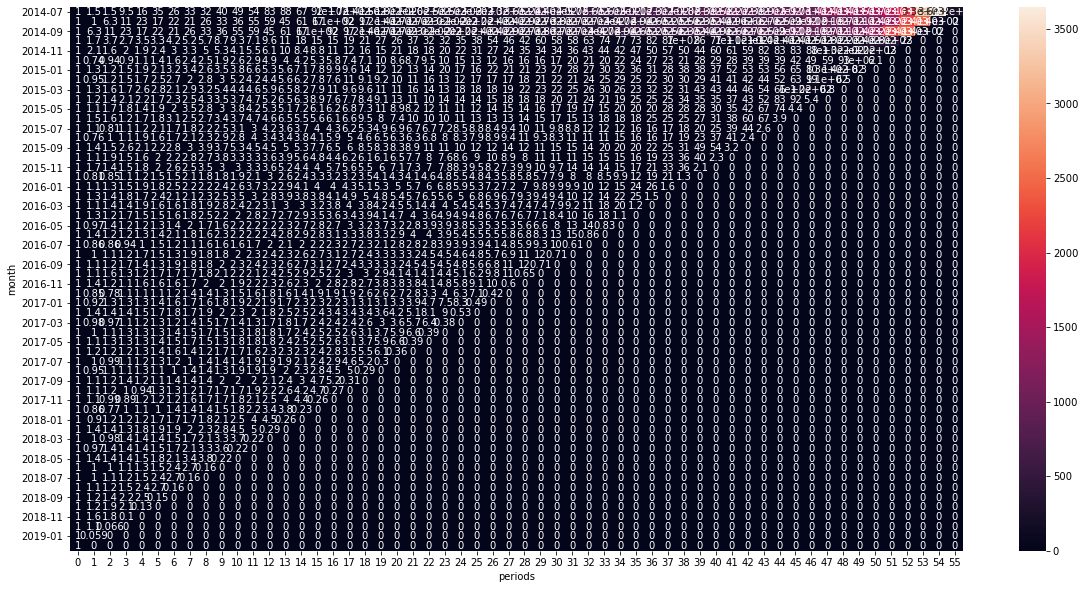

In [24]:
#HOTEL
prod = 'HOTEL'
df_trx_cohort_clean = df[df['last_issued_time_month'].notna()]
df_trx_cohort_clean = df_trx_cohort_clean[['profile_id','last_issued_time_month','primary_sales_product_type']].copy()
df_trx_cohort_clean = df_trx_cohort_clean[df_trx_cohort_clean['primary_sales_product_type']==prod]
df_trx_cohort_clean = df_trx_cohort_clean.groupby('last_issued_time_month',as_index=False)['profile_id'].count()
df1 = df_trx_cohort_clean.copy()
df1.columns =  ['last_trx_time_month','count_trx']
dfs = df1.copy()
dfesis = []
for i in range(len(dfs)):
    #real value
    dfm = dfs.copy().loc[i:]
    dfm['month'] = df1['last_trx_time_month'][i]
    dfm['periods'] = [i for i in range(len(dfm))]
    dfm['prob'] = [(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfm['pcg'] = [100*(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfesis.append(dfm)
dfesis = pd.concat(dfesis,axis=0).sort_values(by=['periods','last_trx_time_month'])
dfesis = dfesis.reset_index().drop('index',axis=1)
dfpivot_trx = dfesis.pivot(index='month',columns='periods',values='count_trx').fillna(0)
dfpivot_prob = dfesis.pivot(index='month',columns='periods',values='prob').fillna(0)
dfpivot_pcg = dfesis.pivot(index='month',columns='periods',values='pcg').fillna(0)
with pd.ExcelWriter(f'new_pivot_{prod}.xlsx') as writer1:
    dfpivot_trx.to_excel(writer1, sheet_name = 'df_trx', index = True)
    dfpivot_prob.to_excel(writer1, sheet_name = 'df_prob', index = True)
    dfpivot_pcg.to_excel(writer1, sheet_name = 'df_pcg', index = True)
plt.figure(figsize=(20,10))
sns.heatmap(dfpivot_prob,annot=True)

<AxesSubplot:xlabel='periods', ylabel='month'>

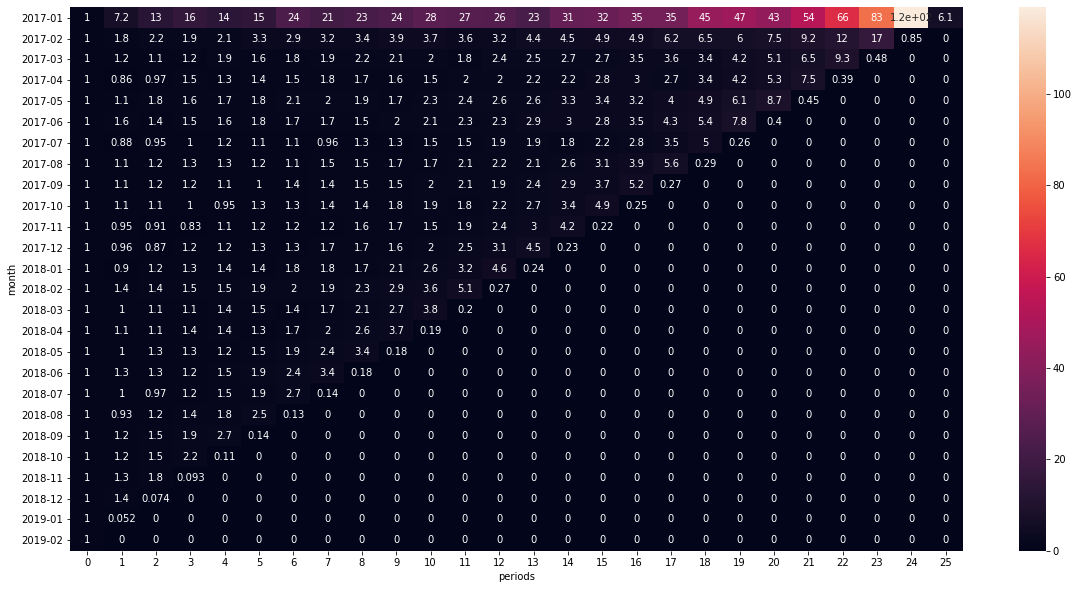

In [25]:
#TRAIN
prod = 'TRAIN'
df_trx_cohort_clean = df[df['last_issued_time_month'].notna()]
df_trx_cohort_clean = df_trx_cohort_clean[['profile_id','last_issued_time_month','primary_sales_product_type']].copy()
df_trx_cohort_clean = df_trx_cohort_clean[df_trx_cohort_clean['primary_sales_product_type']==prod]
df_trx_cohort_clean = df_trx_cohort_clean.groupby('last_issued_time_month',as_index=False)['profile_id'].count()
df1 = df_trx_cohort_clean.copy()
df1.columns =  ['last_trx_time_month','count_trx']
dfs = df1.copy()
dfesis = []
for i in range(len(dfs)):
    #real value
    dfm = dfs.copy().loc[i:]
    dfm['month'] = df1['last_trx_time_month'][i]
    dfm['periods'] = [i for i in range(len(dfm))]
    dfm['prob'] = [(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfm['pcg'] = [100*(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfesis.append(dfm)
dfesis = pd.concat(dfesis,axis=0).sort_values(by=['periods','last_trx_time_month'])
dfesis = dfesis.reset_index().drop('index',axis=1)
dfpivot_trx = dfesis.pivot(index='month',columns='periods',values='count_trx').fillna(0)
dfpivot_prob = dfesis.pivot(index='month',columns='periods',values='prob').fillna(0)
dfpivot_pcg = dfesis.pivot(index='month',columns='periods',values='pcg').fillna(0)
with pd.ExcelWriter(f'new_pivot_{prod}.xlsx') as writer1:
    dfpivot_trx.to_excel(writer1, sheet_name = 'df_trx', index = True)
    dfpivot_prob.to_excel(writer1, sheet_name = 'df_prob', index = True)
    dfpivot_pcg.to_excel(writer1, sheet_name = 'df_pcg', index = True)
plt.figure(figsize=(20,10))
sns.heatmap(dfpivot_prob,annot=True)

<AxesSubplot:xlabel='periods', ylabel='month'>

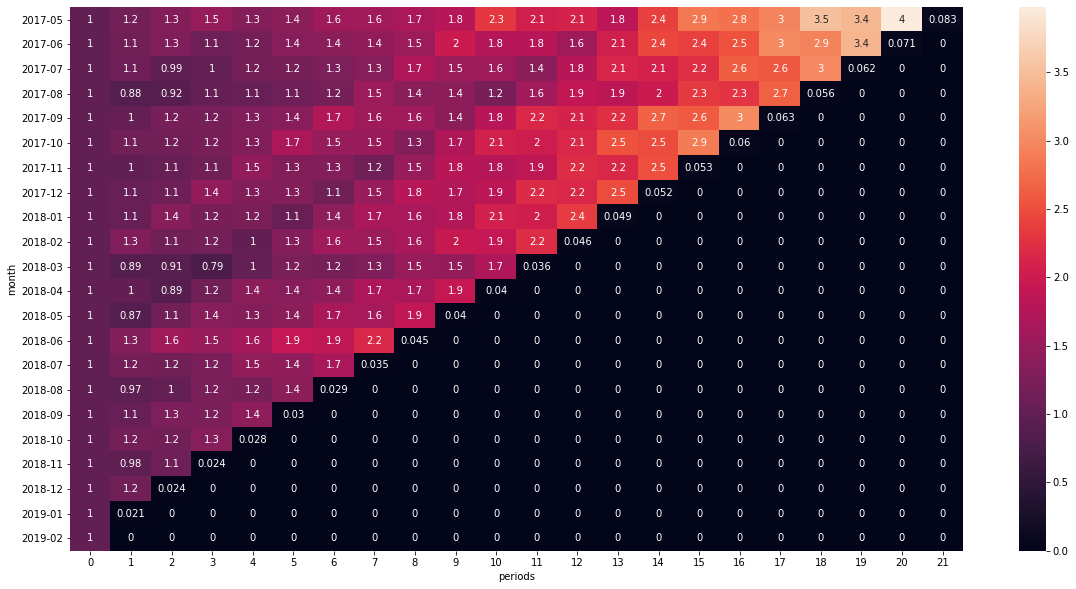

In [26]:
#TRIP
prod = 'TRIP'
df_trx_cohort_clean = df[df['last_issued_time_month'].notna()]
df_trx_cohort_clean = df_trx_cohort_clean[['profile_id','last_issued_time_month','primary_sales_product_type']].copy()
df_trx_cohort_clean = df_trx_cohort_clean[df_trx_cohort_clean['primary_sales_product_type']==prod]
df_trx_cohort_clean = df_trx_cohort_clean.groupby('last_issued_time_month',as_index=False)['profile_id'].count()
df1 = df_trx_cohort_clean.copy()
df1.columns =  ['last_trx_time_month','count_trx']
dfs = df1.copy()
dfesis = []
for i in range(len(dfs)):
    #real value
    dfm = dfs.copy().loc[i:]
    dfm['month'] = df1['last_trx_time_month'][i]
    dfm['periods'] = [i for i in range(len(dfm))]
    dfm['prob'] = [(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfm['pcg'] = [100*(dfm.count_trx[j]/dfm.count_trx[i]) for j in dfm.index]
    dfesis.append(dfm)
dfesis = pd.concat(dfesis,axis=0).sort_values(by=['periods','last_trx_time_month'])
dfesis = dfesis.reset_index().drop('index',axis=1)
dfpivot_trx = dfesis.pivot(index='month',columns='periods',values='count_trx').fillna(0)
dfpivot_prob = dfesis.pivot(index='month',columns='periods',values='prob').fillna(0)
dfpivot_pcg = dfesis.pivot(index='month',columns='periods',values='pcg').fillna(0)
with pd.ExcelWriter(f'new_pivot_{prod}.xlsx') as writer1:
    dfpivot_trx.to_excel(writer1, sheet_name = 'df_trx', index = True)
    dfpivot_prob.to_excel(writer1, sheet_name = 'df_prob', index = True)
    dfpivot_pcg.to_excel(writer1, sheet_name = 'df_pcg', index = True)
plt.figure(figsize=(20,10))
sns.heatmap(dfpivot_prob,annot=True)


The graph overall churn is about 40%, it is very badly for the company due to many churners, but it doesn't mean all product are badly let it breakdown churners for every product types to find out which product has the most churners


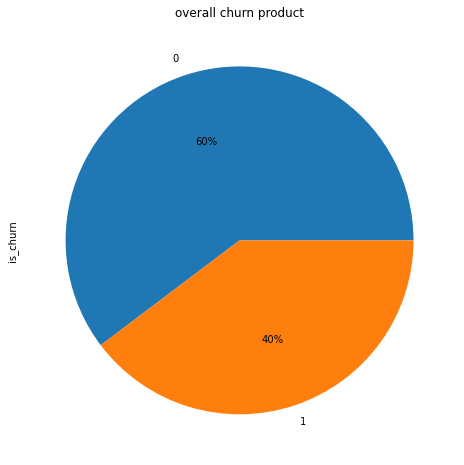

In [27]:
plot = df.is_churn.value_counts().plot.pie(y='is_churn', figsize=(8, 8), autopct='%1.0f%%')
plt.title('overall churn product')
print("""""")
print("""The graph overall churn is about 40%, it is very badly for the company due to many churners, but it doesn't mean all product are badly let it breakdown churners for every product types to find out which product has the most churners""")

In [28]:
np.round((df['primary_sales_product_type'].value_counts(True))*100,2)

FLIGHT    50.30
HOTEL     32.05
TRAIN     15.83
TRIP       1.82
Name: primary_sales_product_type, dtype: float64

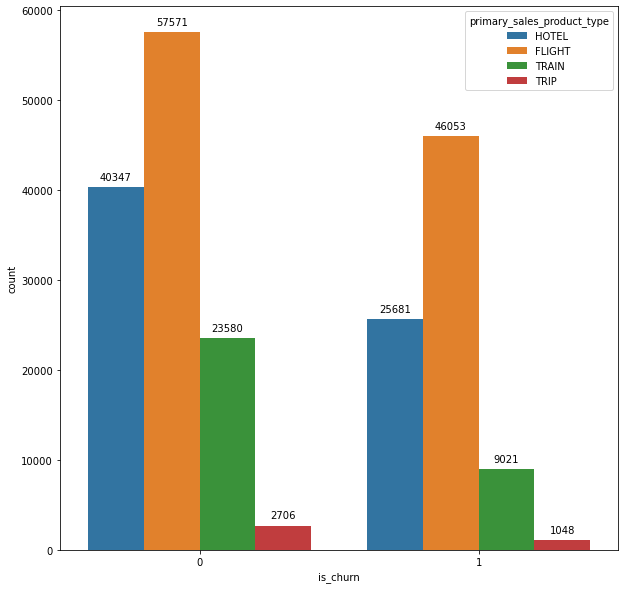

HOTEL Churners
0    0.611059
1    0.388941
Name: is_churn, dtype: float64
Flight Churners
0    0.555576
1    0.444424
Name: is_churn, dtype: float64
TRAIN Churners
0    0.723291
1    0.276709
Name: is_churn, dtype: float64
TRIP Churners
0    0.720831
1    0.279169
Name: is_churn, dtype: float64
Conclusion : Based On graph Product Flight(47%) is the most churnes followed with Hotel (40%)


In [29]:
total = float(len(df))  
plt.figure(figsize=(10, 10))
ax = sns.countplot(x="is_churn", hue="primary_sales_product_type", data=df)
for rect in ax.patches:
    y_value = rect.get_height()
    x_value = rect.get_x() + rect.get_width() / 2
    space = 5
    va = 'bottom'
    label = str(int(y_value))
    plt.annotate(label,(x_value, y_value),xytext=(0, space),textcoords="offset points", ha='center',va=va)
plt.show()
print('HOTEL Churners')
print(df[df['primary_sales_product_type']=='HOTEL']['is_churn'].value_counts(True))
print('Flight Churners')
print(df[df['primary_sales_product_type']=='FLIGHT']['is_churn'].value_counts(True))
print('TRAIN Churners')
print(df[df['primary_sales_product_type']=='TRAIN']['is_churn'].value_counts(True))
print('TRIP Churners')
print(df[df['primary_sales_product_type']=='TRIP']['is_churn'].value_counts(True))
print('Conclusion : Based On graph Product Flight(47%) is the most churnes followed with Hotel (40%)')

conclusion:
1)trave di sebelum tahun 2018 banyak transaksi yang non organik contohnya promo sekali pakai
2)ada secara internal traveloka ada perubahan yang drastis sebelum dan setelah tahun 2018
3)mungkin ada perubahan populasi sebelum 2018, sedangkan populasi mulai dari 2018 mungkin bagus bagus


<AxesSubplot:title={'center':'Population Movement Each Months'}, xlabel='yearmonth'>

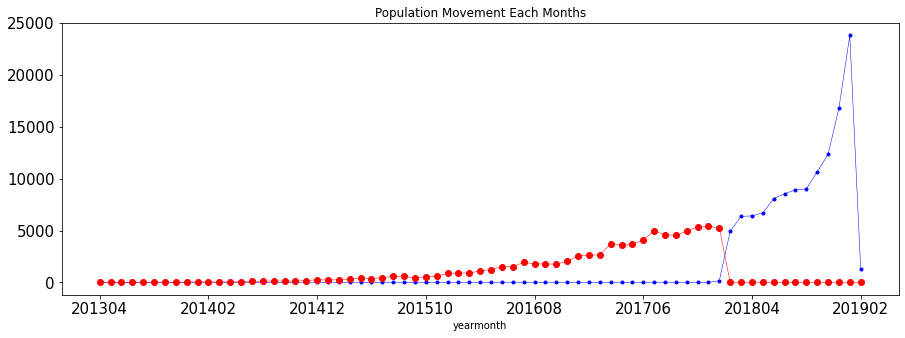

In [30]:
df2 = df.copy().dropna()
dot = []
for i in df2['last_issued_time_date']:
        b = i.strftime("%d/%m/%Y")
        dot.append(b[6:11])
df2['year'] = dot
dot = []
for i in df2['last_issued_time_date']:
        b = i.strftime("%d/%m/%Y")
        dot.append(b[3:5])
df2['month'] = dot
print('conclusion:')
print("""1)trave di sebelum tahun 2018 banyak transaksi yang non organik contohnya promo sekali pakai""")
print("""2)ada secara internal traveloka ada perubahan yang drastis sebelum dan setelah tahun 2018""")
print("""3)mungkin ada perubahan populasi sebelum 2018, sedangkan populasi mulai dari 2018 mungkin bagus bagus""")
df3 = pd.DataFrame(df2[['profile_id','is_churn','year','month']].groupby(['year','month','is_churn'])['profile_id']\
             .count()).reset_index().rename(columns={'profile_id':'count'})
df3['yearmonth'] = df3['year']+df3['month']
df30 = df3[df3['is_churn']==0][['count','yearmonth']]
df31 = df3[df3['is_churn']==1][['count','yearmonth']]
df4 = pd.merge(df30,df31,how = 'outer',on=['yearmonth'])
df4 = df4.set_index('yearmonth').fillna(0).rename(columns={'count_y':'churn','count_x':'not_churn'}).sort_index()
plt.figure(figsize=(15,5))
plt.title('Population Movement Each Months')
df4['not_churn'].plot(marker='.', linestyle='-', linewidth=0.5, c='blue', label = 'not churn',fontsize=15)
df4['churn'].plot(marker='o', linestyle='-', linewidth=0.5, c = 'red', label = 'churn',fontsize=15)

<AxesSubplot:>

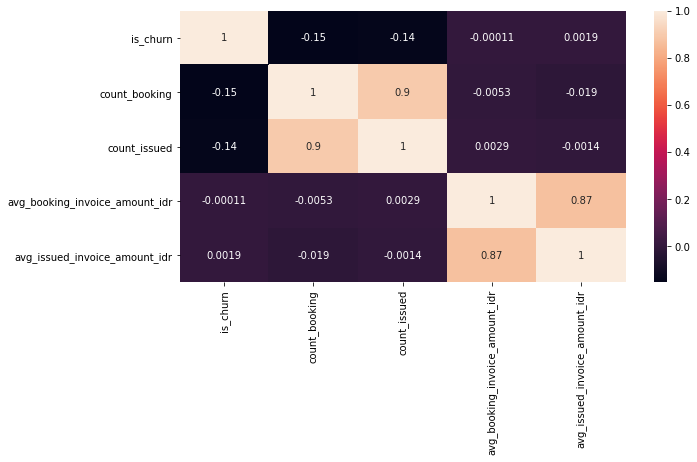

In [31]:
# correlations
#check correlations
plt.figure(figsize=(10,5))
sns.heatmap(df[['is_churn', 'count_booking', 'count_issued', 'avg_booking_invoice_amount_idr',
                'avg_issued_invoice_amount_idr']].corr(),annot=True)

In [32]:
np.round(df2['avg_issued_invoice_amount_idr'].describe())

count      206007.0
mean      1118417.0
std       1485830.0
min             0.0
25%        408175.0
50%        753372.0
75%       1310418.0
max      88993002.0
Name: avg_issued_invoice_amount_idr, dtype: float64

In [33]:
df2 = np.round(df.copy()[['is_churn', 'count_booking', 'avg_booking_invoice_amount_idr', 
               'count_issued', 'avg_issued_invoice_amount_idr']])
df2['count_issued_flag'] = np.where(df['count_issued']<=1,0,
                                    np.where((df['count_issued']>1)&(df['count_issued']<=4),1,2))
df2['count_booking_flag'] = np.where(df['count_booking']<=3,0,np.where((df['count_booking']>3)&(df['count_booking']<=10),1,2))
df2['avg_booking_invoice_amount_idr_flag'] = np.where(df['avg_booking_invoice_amount_idr']<=412143.0,0,
                                    np.where((df['avg_booking_invoice_amount_idr']>412143.0)&(df['avg_booking_invoice_amount_idr']<=770905.0),1,
                                             np.where((df['avg_booking_invoice_amount_idr']>770905.0)&(df['avg_booking_invoice_amount_idr']<=1378235.0),2,3)))
df2['avg_issued_invoice_amount_idr_flag'] = np.where(df['avg_issued_invoice_amount_idr']<=501379.0,0,
                                    np.where((df['avg_issued_invoice_amount_idr']>501379.0)&(df['avg_issued_invoice_amount_idr']<=1063629.0),1,2))
df2.head()

,is_churn,count_booking,avg_booking_invoice_amount_idr,count_issued,avg_issued_invoice_amount_idr,count_issued_flag,count_booking_flag,avg_booking_invoice_amount_idr_flag,avg_issued_invoice_amount_idr_flag
0,0,32,2000823.0,18,1193237.0,2,2,3,2
1,0,58,1174169.0,33,1031982.0,2,2,2,1
2,0,62,284884.0,24,252776.0,2,2,0,0
3,0,36,737447.0,22,587506.0,2,2,1,1
4,0,53,1604698.0,20,1443118.0,2,2,3,2


<AxesSubplot:xlabel='count', ylabel='count_booking_flag'>

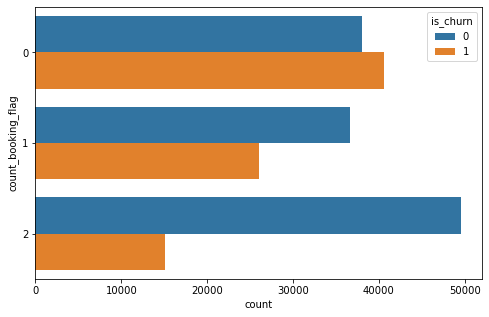

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(y='count_booking_flag',hue='is_churn',data=df2)

In [35]:
print(df2.groupby(['count_booking_flag'])['count_booking'].min().reset_index())
print(df2.groupby(['count_booking_flag'])['count_booking'].max().reset_index())

   count_booking_flag  count_booking
0                   0              1
1                   1              4
2                   2             11
   count_booking_flag  count_booking
0                   0              3
1                   1             10
2                   2           4308


<AxesSubplot:xlabel='count', ylabel='count_issued_flag'>

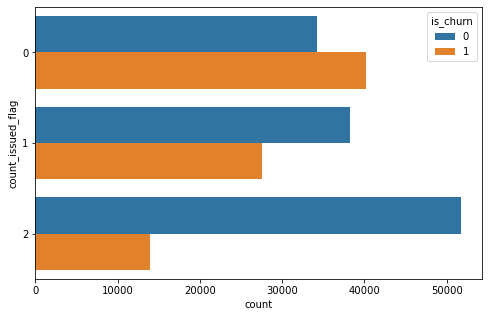

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(y='count_issued_flag',hue='is_churn',data=df2)

In [37]:
print(df2.groupby(['count_issued_flag'])['count_issued'].min().reset_index())
print(df2.groupby(['count_issued_flag'])['count_issued'].max().reset_index())

   count_issued_flag  count_issued
0                  0             1
1                  1             2
2                  2             5
   count_issued_flag  count_issued
0                  0             1
1                  1             4
2                  2          3132


<AxesSubplot:xlabel='count', ylabel='avg_booking_invoice_amount_idr_flag'>

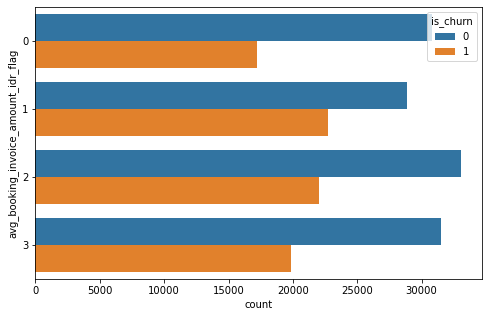

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(y='avg_booking_invoice_amount_idr_flag',hue='is_churn',data=df2)

In [39]:
print(df2.groupby(['avg_booking_invoice_amount_idr_flag'])['avg_booking_invoice_amount_idr'].min().reset_index())
print(df2.groupby(['avg_booking_invoice_amount_idr_flag'])['avg_booking_invoice_amount_idr'].max().reset_index())

   avg_booking_invoice_amount_idr_flag  avg_booking_invoice_amount_idr
0                                    0                             0.0
1                                    1                        412154.0
2                                    2                        770910.0
3                                    3                       1378265.0
   avg_booking_invoice_amount_idr_flag  avg_booking_invoice_amount_idr
0                                    0                        412138.0
1                                    1                        770905.0
2                                    2                       1378235.0
3                                    3                     191527702.0


<AxesSubplot:xlabel='count', ylabel='avg_issued_invoice_amount_idr_flag'>

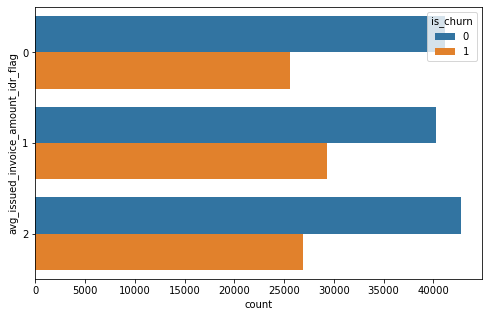

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(y='avg_issued_invoice_amount_idr_flag',hue='is_churn',data=df2)

In [41]:
print(df2.groupby(['avg_issued_invoice_amount_idr_flag'])['avg_issued_invoice_amount_idr'].min().reset_index())
print(df2.groupby(['avg_issued_invoice_amount_idr_flag'])['avg_issued_invoice_amount_idr'].max().reset_index())

   avg_issued_invoice_amount_idr_flag  avg_issued_invoice_amount_idr
0                                   0                            0.0
1                                   1                       501387.0
2                                   2                      1063638.0
   avg_issued_invoice_amount_idr_flag  avg_issued_invoice_amount_idr
0                                   0                       501379.0
1                                   1                      1063629.0
2                                   2                     88993002.0


In [42]:
np.round(df.groupby(['primary_sales_product_type','is_churn']).mean().reset_index().drop('profile_id',axis=1),4).T

,0,1,2,3,4,5,6,7
primary_sales_product_type,FLIGHT,FLIGHT,HOTEL,HOTEL,TRAIN,TRAIN,TRIP,TRIP
is_churn,0,1,0,1,0,1,0,1
avg_booking_invoice_amount_idr,1602087.3956,1456188.9152,879501.5265,871923.3922,335709.0723,339790.5196,3918320.8882,3591999.453
avg_issued_invoice_amount_idr,1525645.0122,1398966.9244,811455.5085,806423.8314,331604.8039,336569.028,3784887.939,3430571.431
count_booking,21.6995,8.2473,15.6906,7.134,14.2682,5.6905,4.7166,3.9628
count_issued,12.7171,4.1219,7.094,2.7228,5.7071,2.0101,1.697,1.2023
first_booking_time_ms,1493745271822.425781,1468050258334.335205,1503289980625.102783,1478338394543.464111,1519824630466.384277,1501145606376.358154,1528500738904.851807,1504888729272.188965
first_issued_time_ms,1498414417143.313965,1471178065808.91333,1508259061254.782715,1480878854342.813965,1521932032243.205322,1501819572626.176025,1530224582110.905029,1505566887342.556396
last_booking_time_ms,1538018321780.109131,1488961702218.551025,1538555359893.163086,1495087216750.154053,1538245093053.507812,1507694160125.543701,1536092467313.623779,1509694595136.307373
last_issued_time_ms,1537015086056.323242,1484461514105.389404,1537460944413.132568,1489613203553.121338,1537243354952.825195,1504138511346.106445,1535207617977.152588,1506352525138.237549


In [43]:
dt = np.round(df[['primary_sales_product_type','count_issued','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['count_issued_y']-dt['count_issued_x'])/dt['count_issued_x'])*100
print('churn = ',dt['count_issued_y'].sum())
print('non churn = ',dt['count_issued_x'].sum())
print(abs(dt['count_issued_y'].sum()-dt['count_issued_x'].sum())/dt['count_issued_x'].sum())
dt

churn =  10.0
non churn =  28.0
0.6428571428571429


,is_churn_x,primary_sales_product_type,count_issued_x,is_churn_y,count_issued_y,pcg
0,0,FLIGHT,13.0,1,4.0,69.230769
1,0,HOTEL,7.0,1,3.0,57.142857
2,0,TRAIN,6.0,1,2.0,66.666667
3,0,TRIP,2.0,1,1.0,50.000000


In [44]:
dt = np.round(df[['primary_sales_product_type','count_booking','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['count_booking_y']-dt['count_booking_x'])/dt['count_booking_x'])*100
print('churn = ',dt['count_booking_y'].sum())
print('non churn = ',dt['count_booking_x'].sum())
print(abs(dt['count_booking_y'].sum()-dt['count_booking_x'].sum())/dt['count_booking_x'].sum())
dt

churn =  25.0
non churn =  57.0
0.5614035087719298


,is_churn_x,primary_sales_product_type,count_booking_x,is_churn_y,count_booking_y,pcg
0,0,FLIGHT,22.0,1,8.0,63.636364
1,0,HOTEL,16.0,1,7.0,56.250000
2,0,TRAIN,14.0,1,6.0,57.142857
3,0,TRIP,5.0,1,4.0,20.000000


In [45]:
dt = np.round(df[['primary_sales_product_type','avg_issued_invoice_amount_idr','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['avg_issued_invoice_amount_idr_y']-dt['avg_issued_invoice_amount_idr_x'])/dt['avg_issued_invoice_amount_idr_x'])*100
print('churn = ',dt['avg_issued_invoice_amount_idr_y'].sum())
print('non churn = ',dt['avg_issued_invoice_amount_idr_x'].sum())
print(abs(dt['avg_issued_invoice_amount_idr_y'].sum()-dt['avg_issued_invoice_amount_idr_x'].sum())/dt['avg_issued_invoice_amount_idr_x'].sum())
dt

churn =  5972531.0
non churn =  6453594.0
0.07454187542631284


,is_churn_x,primary_sales_product_type,avg_issued_invoice_amount_idr_x,is_churn_y,avg_issued_invoice_amount_idr_y,pcg
0,0,FLIGHT,1525645.0,1,1398967.0,8.303242
1,0,HOTEL,811456.0,1,806424.0,0.620120
2,0,TRAIN,331605.0,1,336569.0,1.496962
3,0,TRIP,3784888.0,1,3430571.0,9.361360


In [46]:
dt = np.round(df[['primary_sales_product_type','avg_booking_invoice_amount_idr','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['avg_booking_invoice_amount_idr_y']-dt['avg_booking_invoice_amount_idr_x'])/dt['avg_booking_invoice_amount_idr_x'])*100
print('churn = ',dt['avg_booking_invoice_amount_idr_y'].sum())
print('non churn = ',dt['avg_booking_invoice_amount_idr_x'].sum())
print(abs(dt['avg_booking_invoice_amount_idr_y'].sum()-dt['avg_booking_invoice_amount_idr_x'].sum())/dt['avg_booking_invoice_amount_idr_x'].sum())
dt

churn =  6259902.0
non churn =  6735619.0
0.0706270648621901


,is_churn_x,primary_sales_product_type,avg_booking_invoice_amount_idr_x,is_churn_y,avg_booking_invoice_amount_idr_y,pcg
0,0,FLIGHT,1602087.0,1,1456189.0,9.106746
1,0,HOTEL,879502.0,1,871923.0,0.861738
2,0,TRAIN,335709.0,1,339791.0,1.215934
3,0,TRIP,3918321.0,1,3591999.0,8.328108


In [47]:
df.sort_values(by=['profile_id','last_issued_time_date'])

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn,first_booking_time_month,last_booking_time_month,first_issued_time_month,last_issued_time_month
54068,80027,TRIP,4.916500e+06,5.303097e+06,6,1,1523369893000,1.525830e+12,1525829560000,1.525830e+12,2018-04-10 14:18:13.000,2018-05-09 01:42:16.000000000,2018-05-09 01:32:40.000,2018-05-09 01:42:16.000000000,0,2018-04,2018-05,2018-05,2018-05
163890,80027,HOTEL,5.454916e+05,4.963720e+05,14,5,1531908958509,1.531910e+12,1543573125136,1.543573e+12,2018-07-18 10:15:58.509,2018-07-18 10:26:38.814000128,2018-11-30 10:18:45.136,2018-11-30 10:24:13.535000064,0,2018-07,2018-11,2018-07,2018-11
205254,80027,FLIGHT,8.087514e+05,6.969511e+05,41,16,1386841102957,1.392811e+12,1544024811381,1.544025e+12,2013-12-12 09:38:22.957,2014-02-19 12:03:38.324000000,2018-12-05 15:46:51.381,2018-12-05 15:48:48.856999936,0,2013-12,2018-12,2014-02,2018-12
183240,80138,FLIGHT,1.224204e+06,1.458724e+06,14,8,1376584801416,1.406131e+12,1446545266945,1.443847e+12,2013-08-15 16:40:01.416,2014-07-23 15:50:37.992000000,2015-11-03 10:07:46.945,2015-10-03 04:42:29.732999936,1,2013-08,2015-11,2014-07,2015-10
970,80381,FLIGHT,7.649289e+05,8.464373e+05,26,17,1390929529590,1.449792e+12,1529831417891,1.529832e+12,2014-01-28 17:18:49.590,2015-12-10 23:56:23.545999872,2018-06-24 09:10:17.891,2018-06-24 09:17:54.465999872,0,2014-01,2018-06,2015-12,2018-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28397,104044942,FLIGHT,1.274741e+06,1.274741e+06,1,1,1549024832530,1.549026e+12,1549024832530,1.549026e+12,2019-02-01 12:40:32.530,2019-02-01 12:51:44.934000128,2019-02-01 12:40:32.530,2019-02-01 12:51:44.934000128,0,2019-02,2019-02,2019-02,2019-02
78165,104047320,HOTEL,1.127205e+06,1.127205e+06,1,1,1549026423804,1.549027e+12,1549026423804,1.549027e+12,2019-02-01 13:07:03.804,2019-02-01 13:13:05.673999872,2019-02-01 13:07:03.804,2019-02-01 13:13:05.673999872,0,2019-02,2019-02,2019-02,2019-02
23435,104069370,FLIGHT,5.034600e+06,5.553600e+06,4,1,1549035906318,1.549040e+12,1549039046575,1.549040e+12,2019-02-01 15:45:06.318,2019-02-01 16:46:56.852000000,2019-02-01 16:37:26.575,2019-02-01 16:46:56.852000000,0,2019-02,2019-02,2019-02,2019-02
83654,104073235,HOTEL,3.321680e+05,3.321680e+05,1,1,1549037845352,1.549038e+12,1549037845352,1.549038e+12,2019-02-01 16:17:25.352,2019-02-01 16:24:32.363000064,2019-02-01 16:17:25.352,2019-02-01 16:24:32.363000064,0,2019-02,2019-02,2019-02,2019-02


In [48]:
dfbro = df[['last_issued_time_month','last_issued_time_date']]
dfbro['new_date'] = [i.strftime('%Y-%m-%d') for i in dfbro['last_issued_time_date']]
dfbro = dfbro.sort_values(by='last_issued_time_month')
dfbro = dfbro.groupby('last_issued_time_month',as_index=False)['last_issued_time_date'].count()
dfbro

,last_issued_time_month,last_issued_time_date
0,2013-04,3
1,2013-05,6
2,2013-06,10
3,2013-07,22
4,2013-08,15
5,2013-09,18
6,2013-10,23
7,2013-11,20
8,2013-12,42
9,2014-01,52


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(

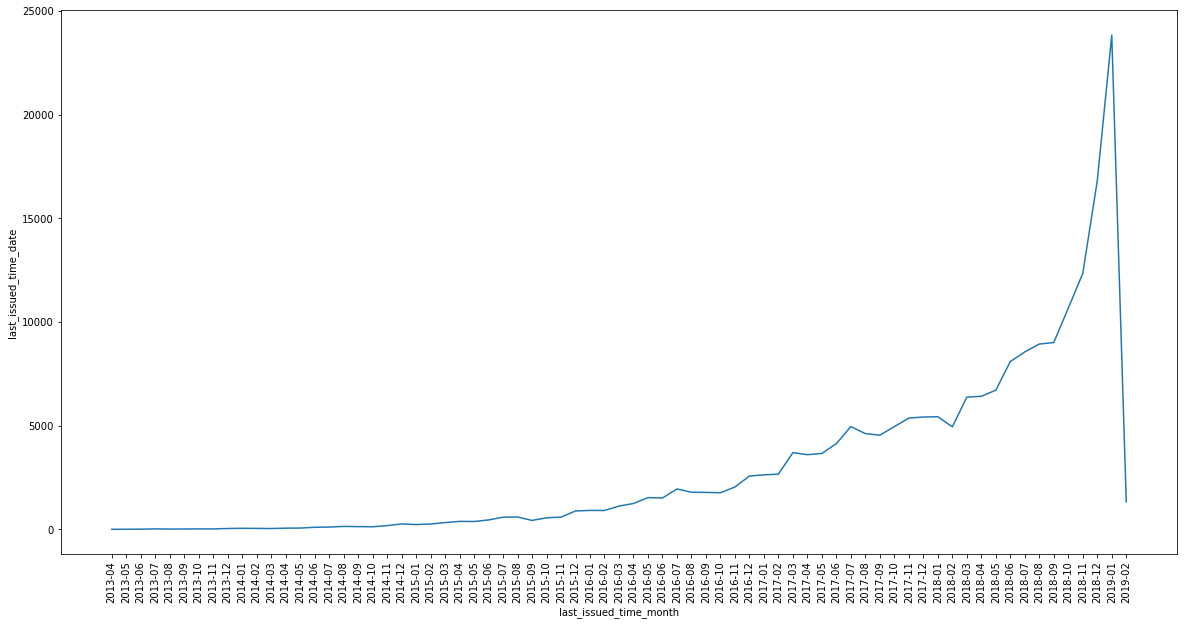

In [49]:
plt.figure(figsize=(20,10))
sns.lineplot(x='last_issued_time_month',y='last_issued_time_date',data=dfbro)
plt.xticks(rotation=90)

In [50]:
print("""1)lets create new features called tenure by substracting last_issued_time_ms and first_booking_time_ms, i assume this tenure from first time and last time customer bought""")
df['tenure_hours'] = (df['last_issued_time_ms']-df['first_booking_time_ms'])/3600000

print("""2)build new features is succes transaction rate = count_issued / count_booking, this features to measure how percentage customer canceling the booking""")
df['pct_succes_trx'] = df['count_issued']/df['count_booking']

print("""3)this features may look average of churn because often to buy expensive product or buying a lot cheaps product""")
df['invoice_per_count_issued'] = (df['avg_issued_invoice_amount_idr']/df['count_issued']).fillna(0)
df['invoice_per_count_booking'] = (df['avg_booking_invoice_amount_idr']/df['count_booking']).fillna(0)

print("""4) To measure how range of distance from first issued to last issued""")
df['diff_last_first_issued_time_days'] = abs(((df['last_issued_time_ms']-df['first_issued_time_ms'])/3600000)/24)
df['diff_last_first_issued_time_days'] = df['diff_last_first_issued_time_days'].fillna(df['diff_last_first_issued_time_days'].median())

print("""5) To measure how range of distance from first booking to last booking""")
df['diff_last_first_booking_time_days'] = abs(((df['last_booking_time_ms']-df['first_booking_time_ms'])/3600000)/24)

print("""6) easy and smoothly payment process from check out until end which means the ui/ux is good""")
df['diff_last_issued_booking_time_hours'] = np.round(abs((df['last_issued_time_ms']-df['last_booking_time_ms'])/3600000),2)
df['diff_last_issued_booking_time_hours'] = df['diff_last_issued_booking_time_hours'].fillna(df['diff_last_issued_booking_time_hours'].median())

df.head()

1)lets create new features called tenure by substracting last_issued_time_ms and first_booking_time_ms, i assume this tenure from first time and last time customer bought
2)build new features is succes transaction rate = count_issued / count_booking, this features to measure how percentage customer canceling the booking
3)this features may look average of churn because often to buy expensive product or buying a lot cheaps product
4) To measure how range of distance from first issued to last issued
5) To measure how range of distance from first booking to last booking
6) easy and smoothly payment process from check out until end which means the ui/ux is good


,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn,first_booking_time_month,last_booking_time_month,first_issued_time_month,last_issued_time_month,tenure_hours,pct_succes_trx,invoice_per_count_issued,invoice_per_count_booking,diff_last_first_issued_time_days,diff_last_first_booking_time_days,diff_last_issued_booking_time_hours
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000,0,2015-07,2018-10,2016-06,2018-10,28337.007566,0.562500,66290.932099,62525.709961,838.127410,1180.702085,0.16
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128,0,2014-07,2018-12,2014-07,2018-12,38902.531547,0.568966,31272.171717,20244.291617,1616.417011,1620.934578,0.10
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000,0,2017-04,2019-01,2017-04,2019-01,15270.677222,0.387097,10532.340278,4594.907648,636.269155,636.255093,0.56
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064,0,2017-04,2019-01,2017-04,2019-01,15078.252754,0.611111,26704.816116,20484.644290,628.254993,628.246526,0.34
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872,0,2015-01,2019-01,2015-04,2018-11,33994.374539,0.377358,72155.915000,30277.314347,1316.119479,1461.250455,1075.64


In [51]:
df['tenure_hours'] = abs(df['tenure_hours'])
df.head()

,profile_id,primary_sales_product_type,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_booking,count_issued,first_booking_time_ms,first_issued_time_ms,last_booking_time_ms,last_issued_time_ms,first_booking_time_date,first_issued_time_date,last_booking_time_date,last_issued_time_date,is_churn,first_booking_time_month,last_booking_time_month,first_issued_time_month,last_issued_time_month,tenure_hours,pct_succes_trx,invoice_per_count_issued,invoice_per_count_booking,diff_last_first_issued_time_days,diff_last_first_booking_time_days,diff_last_issued_booking_time_hours
0,3632279,HOTEL,2.000823e+06,1.193237e+06,32,18,1436705255370,1.466304e+12,1538717915528,1.538718e+12,2015-07-12 12:47:35.370,2016-06-19 02:44:34.396000000,2018-10-05 05:38:35.528,2018-10-05 05:48:02.608000000,0,2015-07,2018-10,2016-06,2018-10,28337.007566,0.562500,66290.932099,62525.709961,838.127410,1180.702085,0.16
1,3632279,FLIGHT,1.174169e+06,1.031982e+06,58,33,1405686647701,1.406077e+12,1545735395212,1.545736e+12,2014-07-18 12:30:47.701,2014-07-23 01:02:11.494000128,2018-12-25 10:56:35.212,2018-12-25 11:02:41.270000128,0,2014-07,2018-12,2014-07,2018-12,38902.531547,0.568966,31272.171717,20244.291617,1616.417011,1620.934578,0.10
2,17407638,TRAIN,2.848843e+05,2.527762e+05,62,24,1493348364000,1.493349e+12,1548320804000,1.548323e+12,2017-04-28 02:59:24.000,2017-04-28 03:12:27.000000000,2019-01-24 09:06:44.000,2019-01-24 09:40:02.000000000,0,2017-04,2019-01,2017-04,2019-01,15270.677222,0.387097,10532.340278,4594.907648,636.269155,636.255093,0.56
3,17407638,HOTEL,7.374472e+05,5.875060e+05,36,22,1493361893998,1.493362e+12,1547642393838,1.547644e+12,2017-04-28 06:44:53.998,2017-04-28 06:52:52.547000064,2019-01-16 12:39:53.838,2019-01-16 13:00:03.911000064,0,2017-04,2019-01,2017-04,2019-01,15078.252754,0.611111,26704.816116,20484.644290,628.254993,628.246526,0.34
4,4618047,FLIGHT,1.604698e+06,1.443118e+06,53,20,1420511473189,1.429178e+12,1546763512498,1.542891e+12,2015-01-06 02:31:13.189,2015-04-16 10:01:38.531000064,2019-01-06 08:31:52.498,2018-11-22 12:53:41.529999872,0,2015-01,2019-01,2015-04,2018-11,33994.374539,0.377358,72155.915000,30277.314347,1316.119479,1461.250455,1075.64


In [52]:
df.head().T

,0,1,2,3,4
profile_id,3632279,3632279,17407638,17407638,4618047
primary_sales_product_type,HOTEL,FLIGHT,TRAIN,HOTEL,FLIGHT
avg_booking_invoice_amount_idr,2000822.71875,1174168.913793,284884.274194,737447.194444,1604697.660377
avg_issued_invoice_amount_idr,1193236.777778,1031981.666667,252776.166667,587505.954545,1443118.3
count_booking,32,58,62,36,53
count_issued,18,33,24,22,20
first_booking_time_ms,1436705255370,1405686647701,1493348364000,1493361893998,1420511473189
first_issued_time_ms,1466304274396.0,1406077331494.0,1493349147000.0,1493362372547.0,1429178498531.0
last_booking_time_ms,1538717915528,1545735395212,1548320804000,1547642393838,1546763512498
last_issued_time_ms,1538718482608.0,1545735761270.0,1548322802000.0,1547643603911.0,1542891221530.0


In [53]:
dt = np.round(df[['primary_sales_product_type','tenure_hours','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['tenure_hours_y']-dt['tenure_hours_x'])/dt['tenure_hours_x'])*100
print('churn = ',dt['tenure_hours_y'].sum())
print('non churn = ',dt['tenure_hours_x'].sum())
print(abs(dt['tenure_hours_y'].sum()-dt['tenure_hours_x'].sum())/dt['tenure_hours_x'].sum())
dt

churn =  8929.0
non churn =  28213.0
0.6835146918087407


,is_churn_x,primary_sales_product_type,tenure_hours_x,is_churn_y,tenure_hours_y,pcg
0,0,FLIGHT,12019.0,1,4559.0,62.068392
1,0,HOTEL,9492.0,1,3132.0,67.003793
2,0,TRAIN,4839.0,1,831.0,82.827030
3,0,TRIP,1863.0,1,407.0,78.153516


In [54]:
dt = df[['primary_sales_product_type','pct_succes_trx','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean()
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['pct_succes_trx_y']-dt['pct_succes_trx_x'])/dt['pct_succes_trx_x'])*100
print('churn = ',0.408180)
print('non churn = ',0.478159)
print('pcg = ',abs(0.408180-0.478159)/0.478159)
dt

churn =  0.40818
non churn =  0.478159
pcg =  0.14635090001443038


,is_churn_x,primary_sales_product_type,pct_succes_trx_x,is_churn_y,pct_succes_trx_y,pcg
0,0,FLIGHT,0.661442,1,0.647768,2.067378
1,0,HOTEL,0.541380,1,0.553398,2.219986
2,0,TRAIN,0.565297,1,0.593647,5.015030
3,0,TRIP,0.646340,1,0.571290,11.611574


In [55]:
dt = np.round(df[['primary_sales_product_type','invoice_per_count_issued','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['invoice_per_count_issued_y']-dt['invoice_per_count_issued_x'])/dt['invoice_per_count_issued_x'])*100
print('churn = ',dt['invoice_per_count_issued_y'].sum())
print('non churn = ',dt['invoice_per_count_issued_x'].sum())
print(abs(dt['invoice_per_count_issued_y'].sum()-dt['invoice_per_count_issued_x'].sum())/dt['invoice_per_count_issued_x'].sum())
dt

churn =  4926419.0
non churn =  4311526.0
0.14261609462635735


,is_churn_x,primary_sales_product_type,invoice_per_count_issued_x,is_churn_y,invoice_per_count_issued_y,pcg
0,0,FLIGHT,623874.0,1,888290.0,42.382917
1,0,HOTEL,381877.0,1,566055.0,48.229666
2,0,TRAIN,179120.0,1,256429.0,43.160451
3,0,TRIP,3126655.0,1,3215645.0,2.846173


In [56]:
dt = np.round(df[['primary_sales_product_type','invoice_per_count_booking','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['invoice_per_count_booking_y']-dt['invoice_per_count_booking_x'])/dt['invoice_per_count_booking_x'])*100
print('churn = ',dt['invoice_per_count_booking_y'].sum())
print('non churn = ',dt['invoice_per_count_booking_x'].sum())
print(abs(dt['invoice_per_count_booking_y'].sum()-dt['invoice_per_count_booking_x'].sum())/dt['invoice_per_count_booking_x'].sum())
dt

churn =  3061848.0
non churn =  2911330.0
0.051700769064310814


,is_churn_x,primary_sales_product_type,invoice_per_count_booking_x,is_churn_y,invoice_per_count_booking_y,pcg
0,0,FLIGHT,435742.0,1,609810.0,39.947492
1,0,HOTEL,225550.0,1,337319.0,49.553979
2,0,TRAIN,107872.0,1,157079.0,45.616101
3,0,TRIP,2142166.0,1,1957640.0,8.613992


In [57]:
dt = np.round(df[['primary_sales_product_type','diff_last_first_issued_time_days','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['diff_last_first_issued_time_days_y']-dt['diff_last_first_issued_time_days_x'])/dt['diff_last_first_issued_time_days_x'])*100
print('churn = ',dt['diff_last_first_issued_time_days_y'].sum())
print('non churn = ',dt['diff_last_first_issued_time_days_x'].sum())
print(abs(dt['diff_last_first_issued_time_days_y'].sum()-dt['diff_last_first_issued_time_days_x'].sum())/dt['diff_last_first_issued_time_days_x'].sum())
dt

churn =  291.0
non churn =  1020.0
0.7147058823529412


,is_churn_x,primary_sales_product_type,diff_last_first_issued_time_days_x,is_churn_y,diff_last_first_issued_time_days_y,pcg
0,0,FLIGHT,447.0,1,154.0,65.548098
1,0,HOTEL,338.0,1,101.0,70.118343
2,0,TRAIN,177.0,1,27.0,84.745763
3,0,TRIP,58.0,1,9.0,84.482759


In [58]:
dt = np.round(df[['primary_sales_product_type','diff_last_first_booking_time_days','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['diff_last_first_booking_time_days_y']-dt['diff_last_first_booking_time_days_x'])/dt['diff_last_first_booking_time_days_x'])*100
print('churn = ',dt['diff_last_first_booking_time_days_y'].sum())
print('non churn = ',dt['diff_last_first_booking_time_days_x'].sum())
print(abs(dt['diff_last_first_booking_time_days_y'].sum()-dt['diff_last_first_booking_time_days_x'].sum())/dt['diff_last_first_booking_time_days_x'].sum())
dt

churn =  568.0
non churn =  1221.0
0.5348075348075348


,is_churn_x,primary_sales_product_type,diff_last_first_booking_time_days_x,is_churn_y,diff_last_first_booking_time_days_y,pcg
0,0,FLIGHT,512.0,1,242.0,52.734375
1,0,HOTEL,408.0,1,194.0,52.450980
2,0,TRAIN,213.0,1,76.0,64.319249
3,0,TRIP,88.0,1,56.0,36.363636


In [59]:
dt = np.round(df[['primary_sales_product_type','diff_last_issued_booking_time_hours','is_churn']].groupby(['is_churn','primary_sales_product_type']).mean())
dt = dt.reset_index()
dt0 = dt[dt['is_churn']==0]
dt1 = dt[dt['is_churn']==1]
dt = pd.merge(dt0, dt1, how = 'inner', on='primary_sales_product_type',)
dt['pcg'] = abs((dt['diff_last_issued_booking_time_hours_y']-dt['diff_last_issued_booking_time_hours_x'])/dt['diff_last_issued_booking_time_hours_x'])*100
print('churn = ',dt['diff_last_issued_booking_time_hours_y'].sum())
print('non churn = ',dt['diff_last_issued_booking_time_hours_x'].sum())
print(abs(dt['diff_last_issued_booking_time_hours_y'].sum()-dt['diff_last_issued_booking_time_hours_x'].sum())/dt['diff_last_issued_booking_time_hours_x'].sum())
dt

churn =  4689.0
non churn =  1108.0
3.2319494584837547


,is_churn_x,primary_sales_product_type,diff_last_issued_booking_time_hours_x,is_churn_y,diff_last_issued_booking_time_hours_y,pcg
0,0,FLIGHT,279.0,1,1251.0,348.387097
1,0,HOTEL,304.0,1,1521.0,400.328947
2,0,TRAIN,279.0,1,988.0,254.121864
3,0,TRIP,246.0,1,929.0,277.642276


In [60]:
num_cols = list(set(df.select_dtypes(np.number).columns.tolist())-set(['is_churn']))
drop_features = ['first_booking_time_ms',
 'first_issued_time_ms',
 'last_booking_time_ms',
 'last_issued_time_ms']
df = df[['primary_sales_product_type']+['is_churn']+num_cols].drop(drop_features,axis=1)
dfs = df.drop('profile_id',axis=1)

### Advanced K-means Clustering

In [61]:
df_scaled = dfs.drop(['is_churn','primary_sales_product_type'],axis=1).copy()
df_scaled.head()

,tenure_hours,avg_booking_invoice_amount_idr,avg_issued_invoice_amount_idr,count_issued,invoice_per_count_issued,invoice_per_count_booking,diff_last_first_booking_time_days,diff_last_first_issued_time_days,diff_last_issued_booking_time_hours,pct_succes_trx,count_booking
0,28337.007566,2.000823e+06,1.193237e+06,18,66290.932099,62525.709961,1180.702085,838.127410,0.16,0.562500,32
1,38902.531547,1.174169e+06,1.031982e+06,33,31272.171717,20244.291617,1620.934578,1616.417011,0.10,0.568966,58
2,15270.677222,2.848843e+05,2.527762e+05,24,10532.340278,4594.907648,636.255093,636.269155,0.56,0.387097,62
3,15078.252754,7.374472e+05,5.875060e+05,22,26704.816116,20484.644290,628.246526,628.254993,0.34,0.611111,36
4,33994.374539,1.604698e+06,1.443118e+06,20,72155.915000,30277.314347,1461.250455,1316.119479,1075.64,0.377358,53


In [62]:
dfs = df_scaled.describe().T.reset_index().copy()
dfs['iqr'] = dfs['75%']-dfs['25%']
dfs['limit_lower_outlier'] = dfs['25%']- 1.5*dfs['iqr']
dfs['limit_upper_outlier'] = dfs['25%'] + 1.5*dfs['iqr']
np.round(dfs[['index','25%','50%','75%','max','iqr','limit_lower_outlier','limit_upper_outlier']],2)

,index,25%,50%,75%,max,iqr,limit_lower_outlier,limit_upper_outlier
0,tenure_hours,1.53,2812.62,11638.02,5.023564e+04,11636.48,-17453.19,17456.26
1,avg_booking_invoice_amount_idr,434616.88,799379.44,1376060.14,1.915277e+08,941443.27,-977548.02,1846781.77
2,avg_issued_invoice_amount_idr,408174.65,753372.33,1310418.50,8.899300e+07,902243.85,-945191.12,1761540.42
3,count_issued,1.00,2.00,6.00,3.132000e+03,5.00,-6.50,8.50
4,invoice_per_count_issued,97472.07,259273.00,629501.00,7.936609e+07,532028.93,-700571.33,895515.47
5,invoice_per_count_booking,47830.80,134826.00,376936.04,7.936609e+07,329105.25,-445827.07,541488.67
6,diff_last_first_booking_time_days,0.52,166.89,529.59,2.104760e+03,529.07,-793.09,794.13
7,diff_last_first_issued_time_days,0.00,56.97,415.88,2.083860e+03,415.88,-623.82,623.82
8,diff_last_issued_booking_time_hours,0.08,0.20,0.89,4.272083e+04,0.81,-1.14,1.30
9,pct_succes_trx,0.35,0.57,1.00,1.000000e+00,0.65,-0.63,1.33


In [63]:
print('upper Outlier Observation Analysis')
print("------------------------------------")
for feature in df_scaled.columns.tolist():
    
    Q1 = df_scaled[feature].quantile(0.25)
    Q3 = df_scaled[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    if df_scaled[(df_scaled[feature] > upper)].any(axis=None):
        print(feature," = yes")
    else:
        print(feature," = no")
print("===================================================")
print('lower Outlier Observation Analysis')
print("------------------------------------")
for feature in df_scaled.columns.tolist():
    
    Q1 = df_scaled[feature].quantile(0.25)
    Q3 = df_scaled[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    if df_scaled[(df_scaled[feature] < lower)].any(axis=None):
        print(feature," = yes")
    else:
        print(feature," = no")

upper Outlier Observation Analysis
------------------------------------
tenure_hours  = yes
avg_booking_invoice_amount_idr  = yes
avg_issued_invoice_amount_idr  = yes
count_issued  = yes
invoice_per_count_issued  = yes
invoice_per_count_booking  = yes
diff_last_first_booking_time_days  = yes
diff_last_first_issued_time_days  = yes
diff_last_issued_booking_time_hours  = yes
pct_succes_trx  = no
count_booking  = yes
lower Outlier Observation Analysis
------------------------------------
tenure_hours  = no
avg_booking_invoice_amount_idr  = no
avg_issued_invoice_amount_idr  = no
count_issued  = no
invoice_per_count_issued  = no
invoice_per_count_booking  = no
diff_last_first_booking_time_days  = no
diff_last_first_issued_time_days  = no
diff_last_issued_booking_time_hours  = no
pct_succes_trx  = no
count_booking  = no


In [64]:
feats = ['count_booking',
'diff_last_issued_booking_time_hours',
'tenure_hours',
'invoice_per_count_issued',
'diff_last_first_issued_time_days',
'count_issued',
'diff_last_first_booking_time_days',
'avg_issued_invoice_amount_idr',
'avg_booking_invoice_amount_idr',
'invoice_per_count_booking']
# low and top imputation Outlier Observation Analysis
for feature in feats:    
    Q1 = df_scaled[feature].quantile(0.25)
    Q3 = df_scaled[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    # upper and lower outlier imputation
    df_scaled.loc[df_scaled[feature]>upper,feature] = upper
    df_scaled.loc[df_scaled[feature]<lower,feature] = lower

In [65]:
# Top Outlier Observation Analysis
for feature in df_scaled.columns.tolist():
    
    Q1 = df_scaled[feature].quantile(0.25)
    Q3 = df_scaled[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    if df_scaled[(df_scaled[feature] > upper)].any(axis=None):
        print(feature,"yes")
    else:
        print(feature, "no")
print("===================================================")
# low Outlier Observation Analysis
for feature in df_scaled.columns.tolist():
    
    Q1 = df_scaled[feature].quantile(0.25)
    Q3 = df_scaled[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1- 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    if df_scaled[(df_scaled[feature] < lower)].any(axis=None):
        print(feature,"yes")
    else:
        print(feature, "no")

tenure_hours no
avg_booking_invoice_amount_idr no
avg_issued_invoice_amount_idr no
count_issued no
invoice_per_count_issued no
invoice_per_count_booking no
diff_last_first_booking_time_days no
diff_last_first_issued_time_days no
diff_last_issued_booking_time_hours no
pct_succes_trx no
count_booking no
tenure_hours no
avg_booking_invoice_amount_idr no
avg_issued_invoice_amount_idr no
count_issued no
invoice_per_count_issued no
invoice_per_count_booking no
diff_last_first_booking_time_days no
diff_last_first_issued_time_days no
diff_last_issued_booking_time_hours no
pct_succes_trx no
count_booking no


In [66]:
num_cols = df_scaled.columns.tolist()
# transform
scaler = StandardScaler()
scaler.fit(df_scaled)
dfscaler = scaler.transform(df_scaled)

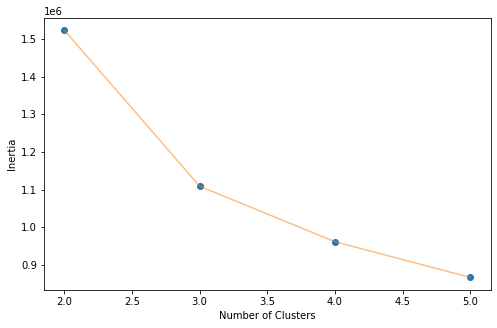

For n_clusters=2, the silhouette score is 0.3280070254477042


In [ ]:
#determine k cluster
ssd = []
range_n_clusters = [2, 3, 4, 5]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=100, random_state=123)
    kmeans.fit(dfscaler)
    ssd.append(kmeans.inertia_)
# plot the SSDs for each n_clusters
plt.figure(1 , figsize = (8 ,5))
plt.plot(range_n_clusters , ssd , 'o')
plt.plot(range_n_clusters , ssd , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()
#Silhouette analysis
range_n_clusters = [2, 3, 4, 5]
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=100, random_state = 123)
    kmeans.fit(dfscaler)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(dfscaler, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

In [67]:
# Final model with k=4
kmeans = KMeans(n_clusters=2, random_state=123, max_iter = 10).fit(dfscaler)
cluster_pred=kmeans.predict(dfscaler)
kmeans_clusters = pd.DataFrame(cluster_pred,columns=['Cluster'])
cluster_center=kmeans.cluster_centers_
# assign the label into dataset
df['cluster'] = cluster_pred
df['cluster'].value_counts().sort_index()

0    143340
1     62667
Name: cluster, dtype: int64

In [68]:
import pickle
# save the model to disk
filename = 'cluster_model.pickle'
pickle.dump(kmeans, open(filename, 'wb'))
# load the model from disk
kmeans = pickle.load(open(filename, 'rb'))

In [167]:
##save to csv
df.to_csv("df_traveloka_03032022.csv",index=False)
df.head()

,primary_sales_product_type,is_churn,diff_last_issued_booking_time_hours,avg_issued_invoice_amount_idr,pct_succes_trx,profile_id,avg_booking_invoice_amount_idr,count_issued,tenure_hours,invoice_per_count_issued,diff_last_first_booking_time_days,invoice_per_count_booking,count_booking,diff_last_first_issued_time_days,cluster
0,HOTEL,0,0.16,1.193237e+06,0.562500,3632279,2.000823e+06,18,28337.007566,66290.932099,1180.702085,62525.709961,32,838.127410,1
1,FLIGHT,0,0.10,1.031982e+06,0.568966,3632279,1.174169e+06,33,38902.531547,31272.171717,1620.934578,20244.291617,58,1616.417011,1
2,TRAIN,0,0.56,2.527762e+05,0.387097,17407638,2.848843e+05,24,15270.677222,10532.340278,636.255093,4594.907648,62,636.269155,1
3,HOTEL,0,0.34,5.875060e+05,0.611111,17407638,7.374472e+05,22,15078.252754,26704.816116,628.246526,20484.644290,36,628.254993,1
4,FLIGHT,0,1075.64,1.443118e+06,0.377358,4618047,1.604698e+06,20,33994.374539,72155.915000,1461.250455,30277.314347,53,1316.119479,1


In [153]:
# proportion churns per cluster
print('Cluster 0')
print(df[df['cluster']==0]['is_churn'].value_counts(True).sort_index())
print('Cluster 1')
print(df[df['cluster']==1]['is_churn'].value_counts(True).sort_index())

Cluster 0
0    0.513555
1    0.486445
Name: is_churn, dtype: float64
Cluster 1
0    0.807299
1    0.192701
Name: is_churn, dtype: float64


In [154]:
df['cluster'].value_counts()

0    143340
1     62667
Name: cluster, dtype: int64

In [155]:
display(df.groupby('cluster')['tenure_hours'].mean())
display(df.groupby('cluster')['diff_last_first_issued_time_days'].mean())
display(df.groupby('cluster')['count_issued'].mean())
display(df.groupby('cluster')['invoice_per_count_issued'].mean())
display(df.groupby('cluster')['avg_issued_invoice_amount_idr'].mean())
display(df.groupby('cluster')['pct_succes_trx'].mean())

cluster
0     2298.834544
1    18556.106435
Name: tenure_hours, dtype: float64

cluster
0     67.123604
1    702.106778
Name: diff_last_first_issued_time_days, dtype: float64

cluster
0     2.093219
1    18.137552
Name: count_issued, dtype: float64

cluster
0    817078.516975
1    127938.292658
Name: invoice_per_count_issued, dtype: float64

cluster
0    1.153571e+06
1    1.038008e+06
Name: avg_issued_invoice_amount_idr, dtype: float64

cluster
0    0.632663
1    0.547548
Name: pct_succes_trx, dtype: float64

In [156]:
df[df['primary_sales_product_type']=='FLIGHT']['cluster'].value_counts()

0    67846
1    35778
Name: cluster, dtype: int64

In [157]:
df[df['primary_sales_product_type']=='HOTEL']['cluster'].value_counts()

0    46170
1    19858
Name: cluster, dtype: int64

In [158]:
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['tenure_hours'].mean())
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['diff_last_first_issued_time_days'].mean())
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['count_issued'].mean())
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['invoice_per_count_issued'].mean())
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['avg_issued_invoice_amount_idr'].mean())
display(df[df['primary_sales_product_type']=='FLIGHT'].groupby('cluster')['pct_succes_trx'].mean())

cluster
0     2508.033661
1    20452.496033
Name: tenure_hours, dtype: float64

cluster
0     74.789833
1    774.973076
Name: diff_last_first_issued_time_days, dtype: float64

cluster
0     2.235519
1    21.529767
Name: count_issued, dtype: float64

cluster
0    1.052969e+06
1    1.505328e+05
Name: invoice_per_count_issued, dtype: float64

cluster
0    1.543373e+06
1    1.328969e+06
Name: avg_issued_invoice_amount_idr, dtype: float64

cluster
0    0.682974
1    0.603011
Name: pct_succes_trx, dtype: float64

In [159]:
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['tenure_hours'].mean())
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['diff_last_first_issued_time_days'].mean())
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['count_issued'].mean())
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['invoice_per_count_issued'].mean())
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['avg_issued_invoice_amount_idr'].mean())
display(df[df['primary_sales_product_type']=='HOTEL'].groupby('cluster')['pct_succes_trx'].mean())

cluster
0     2356.437794
1    17857.007081
Name: tenure_hours, dtype: float64

cluster
0     64.395246
1    667.725165
Name: diff_last_first_issued_time_days, dtype: float64

cluster
0     1.943643
1    13.415651
Name: count_issued, dtype: float64

cluster
0    597989.373840
1    117599.611372
Name: invoice_per_count_issued, dtype: float64

cluster
0    825269.395001
1    772830.992346
Name: avg_issued_invoice_amount_idr, dtype: float64

cluster
0    0.574174
1    0.480675
Name: pct_succes_trx, dtype: float64

In [160]:
# proportion product flight churns per cluster
print('Cluster 0')
print(df[(df['cluster']==0) & (df['primary_sales_product_type']=='FLIGHT')]['is_churn'].value_counts(True).sort_index())
print('Cluster 1')
print(df[(df['cluster']==1) & (df['primary_sales_product_type']=='FLIGHT')]['is_churn'].value_counts(True).sort_index())

Cluster 0
0    0.446732
1    0.553268
Name: is_churn, dtype: float64
Cluster 1
0    0.761977
1    0.238023
Name: is_churn, dtype: float64


In [161]:
# proportion product Hotel churns per cluster
print('Cluster 0')
print(df[(df['cluster']==0) & (df['primary_sales_product_type']=='HOTEL')]['is_churn'].value_counts(True).sort_index())
print('Cluster 1')
print(df[(df['cluster']==1) & (df['primary_sales_product_type']=='HOTEL')]['is_churn'].value_counts(True).sort_index())

Cluster 0
0    0.514901
1    0.485099
Name: is_churn, dtype: float64
Cluster 1
0    0.834626
1    0.165374
Name: is_churn, dtype: float64


In [162]:
# proportion product train churns per cluster
print('Cluster 0')
print(df[(df['cluster']==0) & (df['primary_sales_product_type']=='TRAIN')]['is_churn'].value_counts(True).sort_index())
print('Cluster 1')
print(df[(df['cluster']==1) & (df['primary_sales_product_type']=='TRAIN')]['is_churn'].value_counts(True).sort_index())

Cluster 0
0    0.659011
1    0.340989
Name: is_churn, dtype: float64
Cluster 1
0    0.960316
1    0.039684
Name: is_churn, dtype: float64


In [163]:
# proportion product trip churns per cluster
print('Cluster 0')
print(df[(df['cluster']==0) & (df['primary_sales_product_type']=='TRIP')]['is_churn'].value_counts(True).sort_index())
print('Cluster 1')
print(df[(df['cluster']==1) & (df['primary_sales_product_type']=='TRIP')]['is_churn'].value_counts(True).sort_index())

Cluster 0
0    0.715063
1    0.284937
Name: is_churn, dtype: float64
Cluster 1
0    1.0
Name: is_churn, dtype: float64


In [166]:
#summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206007 entries, 0 to 206006
Data columns (total 15 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   primary_sales_product_type           206007 non-null  object 
 1   is_churn                             206007 non-null  int32  
 2   diff_last_issued_booking_time_hours  206007 non-null  float64
 3   avg_issued_invoice_amount_idr        206007 non-null  float64
 4   pct_succes_trx                       206007 non-null  float64
 5   profile_id                           206007 non-null  int64  
 6   avg_booking_invoice_amount_idr       206007 non-null  float64
 7   count_issued                         206007 non-null  int64  
 8   tenure_hours                         206007 non-null  float64
 9   invoice_per_count_issued             206007 non-null  float64
 10  diff_last_first_booking_time_days    206007 non-null  float64
 11  invoice_per_c

# Finish